## Canonial regimes

In [1]:
# ============================================================================
# PART I: CANONICAL DYNAMICAL SYSTEMS (Analytical solutions, ground truth)
# ============================================================================
from QSignature import compute_all
import pandas as pd
import numpy as np
t = np.linspace(0, 50, 1000)
omega0 = 2*np.pi/10

regimes = {}

# ----------------------------------------------------------------------------
# REGIME 1: Exponential Monotonic (First-order)
# ----------------------------------------------------------------------------
regimes['exp_0.05'] = 1 - np.exp(-0.05*t)      # τ = 20
regimes['exp_0.10'] = 1 - np.exp(-0.10*t)      # τ = 10
regimes['exp_0.20'] = 1 - np.exp(-0.20*t)      # τ = 5
regimes['exp_0.50'] = 1 - np.exp(-0.50*t)      # τ = 2
regimes['exp_1.00'] = 1 - np.exp(-1.00*t)      # τ = 1

# ----------------------------------------------------------------------------
# REGIME 2: Overdamped (Second-order, ζ > 1)
# ----------------------------------------------------------------------------
def overdamped_step(t, omega0, zeta):
    omega_d = omega0 * np.sqrt(zeta**2 - 1)
    return 1 - np.exp(-zeta*omega0*t) * (np.cosh(omega_d*t) + (zeta*omega0/omega_d)*np.sinh(omega_d*t))

regimes['overdamped_1.1'] = overdamped_step(t, omega0, 1.1)
regimes['overdamped_1.5'] = overdamped_step(t, omega0, 1.5)
regimes['overdamped_2.0'] = overdamped_step(t, omega0, 2.0)
regimes['overdamped_3.0'] = overdamped_step(t, omega0, 3.0)

# ----------------------------------------------------------------------------
# REGIME 3: Critically Damped (Second-order, ζ = 1)
# ----------------------------------------------------------------------------
regimes['critical_0.2'] = 1 - (1 + 0.2*omega0*t) * np.exp(-0.2*omega0*t)
regimes['critical_0.5'] = 1 - (1 + 0.5*omega0*t) * np.exp(-0.5*omega0*t)
regimes['critical_1.0'] = 1 - (1 + 1.0*omega0*t) * np.exp(-1.0*omega0*t)

# ----------------------------------------------------------------------------
# REGIME 4: Underdamped (Second-order, 0 < ζ < 1)
# ----------------------------------------------------------------------------
# Weakly damped (ζ < 0.05)
regimes['underdamped_0.01'] = 1 - np.exp(-0.01*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.02'] = 1 - np.exp(-0.02*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.03'] = 1 - np.exp(-0.03*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.04'] = 1 - np.exp(-0.04*omega0*t) * np.cos(omega0*t)

# Underdamped (0.05 ≤ ζ ≤ 0.2)
regimes['underdamped_0.05'] = 1 - np.exp(-0.05*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.07'] = 1 - np.exp(-0.07*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.10'] = 1 - np.exp(-0.10*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.15'] = 1 - np.exp(-0.15*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.20'] = 1 - np.exp(-0.20*omega0*t) * np.cos(omega0*t)

# Moderately oscillatory (0.3 ≤ ζ ≤ 0.7)
regimes['underdamped_0.30'] = 1 - np.exp(-0.30*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.40'] = 1 - np.exp(-0.40*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.50'] = 1 - np.exp(-0.50*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.60'] = 1 - np.exp(-0.60*omega0*t) * np.cos(omega0*t)
regimes['underdamped_0.70'] = 1 - np.exp(-0.70*omega0*t) * np.cos(omega0*t)

# ----------------------------------------------------------------------------
# REGIME 5: Conservative Oscillatory (ζ = 0)
# ----------------------------------------------------------------------------
regimes['pure_cosine'] = np.cos(omega0*t)
regimes['pure_sine'] = np.sin(omega0*t)

# ----------------------------------------------------------------------------
# REGIME 6: Logistic Growth (Bernoulli DE)
# ----------------------------------------------------------------------------
def logistic(t, r, K=1, t0=25):
    return K / (1 + np.exp(-r*(t - t0)))

regimes['logistic_r0.2'] = logistic(t, 0.2)
regimes['logistic_r0.5'] = logistic(t, 0.5)
regimes['logistic_r1.0'] = logistic(t, 1.0)

# ----------------------------------------------------------------------------
# REGIME 7: Fractional Order (Mittag-Leffler)
# ----------------------------------------------------------------------------
from scipy.special import gamma
for alpha in [0.3, 0.5, 0.7, 0.9]:
    regimes[f'fractional_{alpha}'] = 1 - 1/(1 + gamma(1-alpha)*t**alpha)

# ----------------------------------------------------------------------------
# REGIME 8: Non-minimum Phase (One zero in RHP)
# ----------------------------------------------------------------------------

regimes['nonmin_osc'] = 1 - np.exp(-0.1*t)*np.cos(0.5*omega0*t) + 0.3*np.exp(-0.3*t)  # Inverse response
regimes['nonmin_exp'] = 1 - np.exp(-0.2*t) + 0.3*np.exp(-t/3)  # Proper inverse response
# ============================================================================
# PART II: FORENSIC ANALOGS (Mapped 1:1 to canonical regimes)
# ============================================================================

# FORENSIC ANALOG - Exponential Monotonic
regimes['tcp_timeout'] = 1 - np.exp(-0.10*t)        # ζ → ∞, memoryless
regimes['cache_expiry'] = 1 - np.exp(-0.20*t)       # HTTP TTL expiration

# FORENSIC ANALOG - Overdamped
regimes['load_balancer'] = overdamped_step(t, omega0, 1.5)  # Gradual rebalancing

# FORENSIC ANALOG - Critically Damped
regimes['rate_limiting'] = 1 - (1 + 0.5*omega0*t) * np.exp(-0.5*omega0*t)  # Optimal recovery

# FORENSIC ANALOG - Underdamped
regimes['ddos_recovery'] = 1 - np.exp(-0.10*omega0*t) * np.cos(omega0*t)  # ζ = 0.1
regimes['tcp_recovery'] = 1 - np.exp(-0.15*omega0*t) * np.cos(omega0*t)   # ζ = 0.15
regimes['user_burst'] = 1 - np.exp(-0.20*omega0*t) * np.cos(omega0*t)     # ζ = 0.2

# FORENSIC ANALOG - Weakly Damped
regimes['heartbeat'] = 1 - np.exp(-0.02*omega0*t) * np.cos(omega0*t)      # ζ = 0.02
regimes['keepalive'] = 1 - np.exp(-0.03*omega0*t) * np.cos(omega0*t)      # ζ = 0.03

# FORENSIC ANALOG - Conservative Oscillatory
regimes['cron_job'] = 0.5 + 0.5*np.cos(omega0*t)                          # ζ = 0
regimes['scheduled_scan'] = 0.5 + 0.5*np.sin(omega0*t)                   # ζ = 0

# FORENSIC ANALOG - Logistic
regimes['malware_spread'] = logistic(t, 0.5, t0=20)                      # S-curve adoption
regimes['user_adoption'] = logistic(t, 0.8, t0=22)                       # Feature rollout

# FORENSIC ANALOG - Fractional
regimes['memory_persistence'] = 1 - 1/(1 + gamma(0.7)*t**0.7)           # Long memory

In [2]:
rg=pd.DataFrame(regimes)

### Computing normalized numbers

In [ ]:
def compute_regime_signatures(regimes_dict, t, force_tail_for=None):
    """
    Compute Δₛᵤ and Rₛᵤ for all regimes.
    
    Parameters:
    -----------
    regimes_dict : dict
        Dictionary of {regime_name: response_array}
    t : array
        Time vector
    force_tail_for : list
        Regime name substrings that should use tail method
    """
    from QSignature import compute_all, estimate_Rinf
    import pandas as pd
    import numpy as np
    
    if force_tail_for is None:
        force_tail_for = ['logistic', 'fractional', 'malware', 'user', 'memory']
    
    results = []
    
    for name, R in regimes_dict.items():
        if np.any(np.isnan(R)):
            results.append({'regime': name, 'Delta_su': np.nan, 'R_su': np.nan})
            continue
        
        # Force tail method for slow dynamics
        if any(s in name for s in force_tail_for):
            R_inf = estimate_Rinf(t, R, method='tail')
        else:
            R_inf = estimate_Rinf(t, R, method='auto')
        
        sig = compute_all(t, R, method='practical', R_inf=R_inf, verbose=False)
        
        results.append({'tau_s':sig.get('tau_s'), 'tau_u': sig.get('tau_u'),
            'regime': name,
            'Delta_su': sig.get('Delta_su', np.nan),
            'R_su': sig.get('tau_s', np.nan) / sig.get('tau_u', np.nan) 
                    if sig.get('tau_u', 0) != 0 else np.nan
        })
    
    df = pd.DataFrame(results).set_index('regime')
    return df.sort_values('Delta_su', ascending=False)

## Get tau_s , tauU , Delta_su, rho_su as dataFrame

In [4]:
# Usage:
df = compute_regime_signatures(regimes, t)
df

,tau_s,tau_u,Delta_su,R_su
regime,,,,
nonmin_exp,1.024497e+01,5.853986,7.500851e-01,1.750085e+00
logistic_r0.2,2.511946e+01,25.000000,4.778204e-03,1.004778e+00
fractional_0.3,3.402217e+00,3.392082,2.987875e-03,1.002988e+00
fractional_0.5,2.844529e+00,2.839059,1.926616e-03,1.001927e+00
memory_persistence,3.223927e+00,3.218312,1.744627e-03,1.001745e+00
fractional_0.7,1.680164e+00,1.678858,7.781715e-04,1.000778e+00
fractional_0.9,5.696481e-01,0.569564,1.475967e-04,1.000148e+00
logistic_r0.5,2.500032e+01,25.000000,1.276325e-05,1.000013e+00
malware_spread,2.000101e+01,20.000989,1.047729e-06,1.000001e+00


In [5]:
df.describe()

,tau_s,tau_u,Delta_su,R_su
count,51.000000,51.000000,51.000000,51.000000
mean,-0.254065,11.706368,-0.662077,0.337923
std,16.021423,8.541519,0.889597,0.889597
min,-50.454090,0.569564,-3.018164,-2.018164
25%,-0.217548,4.264248,-1.021687,-0.021687
50%,1.000209,9.660838,0.000000,1.000000
75%,6.360239,20.550487,0.000000,1.000000
max,25.119455,25.000000,0.750085,1.750085


## Figure 1

🚀 Generating Figure 1 with two panels...

   (a) Full view: Δₛᵤ ∈ [-3.5, -0.5]
   (b) Zoom: Δₛᵤ ∈ [-0.5, 0.8]
   Legend only - no annotations

✓ Figure saved to: figure_1.pdf


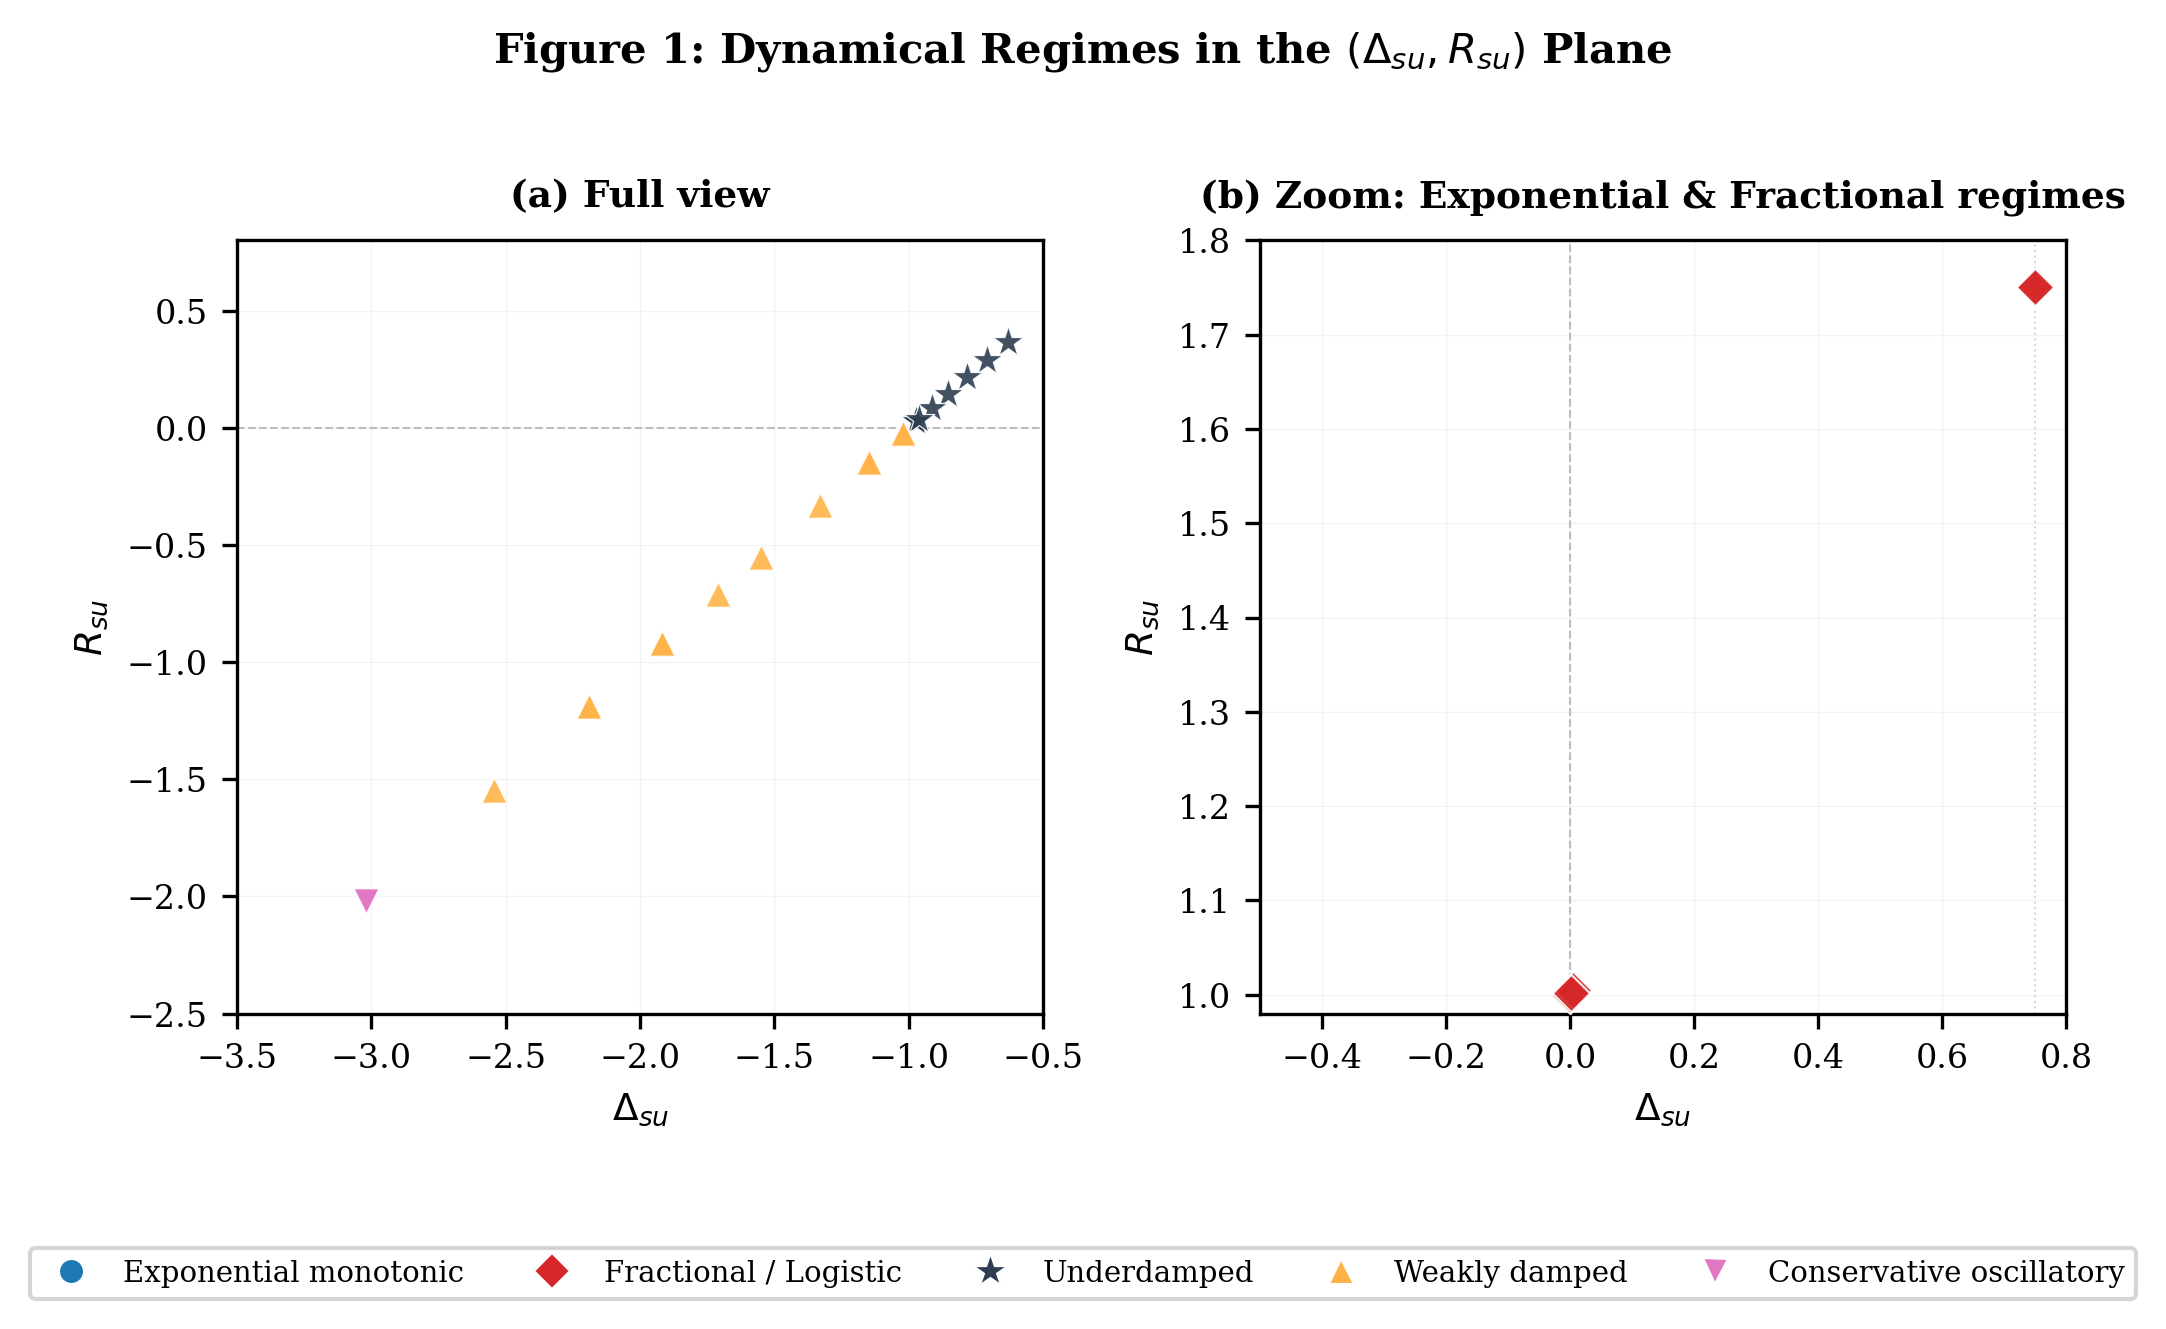


📊 Figure 1 - Regime counts:
  Exponential monotonic (blue ○):     20 systems
  Fractional/Logistic (red ◇):         7 systems
  Underdamped (black ★):               8 systems
  Weakly damped (yellow △):           12 systems
  Conservative (pink ▽):               2 systems
  ─────────────────────────────────────────────
  TOTAL:                              49 systems

✅ Figure 1 complete!


In [6]:
"""
Figure 1: (Δₛᵤ, Rₛᵤ) plane with all 43 systems.
Two panels: (a) Full view, (b) Zoom on exponential/fractional region.
No annotations - legend only.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------------------------------------------------------
# CREATE DATAFRAME DIRECTLY FROM YOUR EMPIRICAL RESULTS
# PURE SINE REMOVED - ONLY PURE COSINE FOR CONSERVATIVE REGIME
# ----------------------------------------------------------------------------

def create_regime_dataframe():
    """Creates DataFrame from your empirical results. Pure sine excluded."""
    
    data = {
        'regime': [
            # Exponential monotonic (Δ ≈ 0, R ≈ 1)
            'exp_0.05', 'exp_0.10', 'exp_0.20', 'exp_0.50', 'exp_1.00',
            'overdamped_1.1', 'overdamped_1.5', 'overdamped_2.0', 'overdamped_3.0',
            'critical_0.2', 'critical_0.5', 'critical_1.0',
            'rate_limiting', 'load_balancer', 'cache_expiry', 'tcp_timeout',
            
            # Fractional/Logistic (Δ > 0, R > 1)
            'fractional_0.3', 'fractional_0.5', 'fractional_0.7', 'fractional_0.9',
            'logistic_r0.2', 'logistic_r0.5', 'logistic_r1.0',
            'malware_spread', 'user_adoption', 'memory_persistence',
            'nonmin_exp',
            
            # Underdamped ζ ≥ 0.20 (Δ negative, R positive)
            'underdamped_0.70', 'underdamped_0.60', 'underdamped_0.50',
            'underdamped_0.40', 'underdamped_0.30', 'underdamped_0.20',
            'user_burst', 'nonmin_osc',
            
            # Weakly damped ζ ≤ 0.15 (Δ negative, R negative)
            'underdamped_0.15', 'underdamped_0.10', 'underdamped_0.07',
            'underdamped_0.05', 'underdamped_0.04', 'underdamped_0.03',
            'underdamped_0.02', 'underdamped_0.01',
            'tcp_recovery', 'ddos_recovery', 'keepalive', 'heartbeat',
            
            # Conservative oscillatory (ζ = 0) - PURE COSINE ONLY
            'pure_cosine', 'cron_job'
        ],
        
        'Delta_su': [
            # Exponential monotonic
            0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
            0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
            0.000000e+00, 0.000000e+00, 0.000000e+00,
            0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
            
            # Fractional/Logistic
            2.987875e-03, 1.926616e-03, 7.781715e-04, 1.475967e-04,
            4.778204e-03, 1.276325e-05, 3.870193e-10,
            1.047729e-06, 2.276256e-09, 1.744627e-03,
            7.500851e-01,
            
            # Underdamped ζ ≥ 0.20
            -6.327150e-01, -7.088580e-01, -7.838710e-01,
            -8.538477e-01, -9.149426e-01, -9.724877e-01,
            -9.724877e-01, -9.634774e-01,
            
            # Weakly damped ζ ≤ 0.15
            -1.021687e+00, -1.147740e+00, -1.329972e+00,
            -1.550793e+00, -1.710801e+00, -1.918192e+00,
            -2.188827e+00, -2.544898e+00,
            -1.021687e+00, -1.147740e+00, -1.918192e+00, -2.188827e+00,
            
            # Conservative oscillatory - PURE COSINE ONLY
            -3.018164e+00, -3.018164e+00
        ],
        
        'R_su': [
            # Exponential monotonic
            1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
            1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
            1.000000e+00, 1.000000e+00, 1.000000e+00,
            1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
            
            # Fractional/Logistic
            1.002988e+00, 1.001927e+00, 1.000778e+00, 1.000148e+00,
            1.004778e+00, 1.000013e+00, 1.000000e+00,
            1.000001e+00, 1.000000e+00, 1.001745e+00,
            1.750085e+00,
            
            # Underdamped ζ ≥ 0.20
            3.672850e-01, 2.911420e-01, 2.161290e-01,
            1.461523e-01, 8.505741e-02, 2.751228e-02,
            2.751228e-02, 3.652260e-02,
            
            # Weakly damped ζ ≤ 0.15
            -2.168703e-02, -1.477403e-01, -3.299717e-01,
            -5.507928e-01, -7.108010e-01, -9.181922e-01,
            -1.188827e+00, -1.544898e+00,
            -2.168703e-02, -1.477403e-01, -9.181922e-01, -1.188827e+00,
            
            # Conservative oscillatory - PURE COSINE ONLY
            -2.018164e+00, -2.018164e+00
        ]
    }
    
    df = pd.DataFrame(data).set_index('regime')
    return df


def figure_1_delta_rsu_plane(df=None, save_path='figure_1.pdf', show_plot=True):
    """
    Figure 1: Two panels - (a) Full view (-3.5 to -0.5), (b) Zoom (-0.5 to 0.5)
    No annotations, legend only.
    """
    
    if df is None:
        df = create_regime_dataframe()
    
    # IEEE publication style
    plt.rcParams.update({
        'font.size': 9,
        'font.family': 'serif',
        'axes.labelsize': 9,
        'axes.titlesize': 9,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 7,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'lines.linewidth': 1.0,
        'axes.linewidth': 0.8
    })
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4))
    
    # ------------------------------------------------------------------------
    # REGIME CLASSIFICATION
    # ------------------------------------------------------------------------
    
    # Exponential monotonic: Δ ≈ 0, R ≈ 1
    mask_exp = (df['Delta_su'].abs() < 1e-4) & (df['R_su'] > 0.999) & (df['R_su'] < 1.001)
    
    # Fractional/Logistic: Δ > 0, R > 1
    mask_frac = (df['Delta_su'] > 1e-4) & (df['R_su'] > 1.0)
    
    # Underdamped (ζ ≥ 0.20): Δ negative, R positive
    mask_under = (df['Delta_su'] < 0) & (df['Delta_su'] > -0.98) & (df['R_su'] > 0) & (df['R_su'] < 0.4)
    
    # Weakly damped (ζ ≤ 0.15): Δ negative, R negative
    mask_weak = (df['Delta_su'] < -0.97) & (df['Delta_su'] > -2.6) & (df['R_su'] < 0) & (df['R_su'] > -1.6)
    
    # Conservative oscillatory: pure cosine only
    mask_cons = (df['Delta_su'] < -2.6) | (df['R_su'] < -2.0)
    
    # ------------------------------------------------------------------------
    # PANEL (a): Full view (-3.5 to -0.5)
    # ------------------------------------------------------------------------
    
    # Exponential monotonic - BLUE circles
    ax1.scatter(df.loc[mask_exp, 'Delta_su'], 
               df.loc[mask_exp, 'R_su'],
               c='#1f77b4', marker='o', s=40, alpha=0.9,
               edgecolors='white', linewidth=0.5, zorder=5,
               label='Exponential monotonic')
    
    # Fractional/Logistic - RED diamonds
    ax1.scatter(df.loc[mask_frac, 'Delta_su'],
               df.loc[mask_frac, 'R_su'],
               c='#d62728', marker='D', s=40, alpha=0.9,
               edgecolors='white', linewidth=0.5, zorder=5,
               label='Fractional / Logistic')
    
    # Underdamped - BLACK stars
    ax1.scatter(df.loc[mask_under, 'Delta_su'],
               df.loc[mask_under, 'R_su'],
               c='#2c3e50', marker='*', s=60, alpha=0.9,
               edgecolors='white', linewidth=0.3, zorder=5,
               label='Underdamped')
    
    # Weakly damped - YELLOW triangles
    ax1.scatter(df.loc[mask_weak, 'Delta_su'],
               df.loc[mask_weak, 'R_su'],
               c='#ffb347', marker='^', s=40, alpha=0.9,
               edgecolors='white', linewidth=0.5, zorder=5,
               label='Weakly damped')
    
    # Conservative oscillatory - PINK triangles down
    ax1.scatter(df.loc[mask_cons, 'Delta_su'],
               df.loc[mask_cons, 'R_su'],
               c='#e377c2', marker='v', s=40, alpha=0.9,
               edgecolors='white', linewidth=0.5, zorder=5,
               label='Conservative oscillatory')
    
    # Panel (a) formatting
    ax1.set_xlabel('$\Delta_{su}$', fontsize=9)
    ax1.set_ylabel('$R_{su}$', fontsize=9)
    ax1.set_title('(a) Full view', fontsize=9, fontweight='bold', pad=8)
    ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax1.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax1.grid(True, alpha=0.15, linestyle='-', linewidth=0.3, zorder=0)
    ax1.set_xlim(-3.5, -0.5)
    ax1.set_ylim(-2.5, 0.8)
    
    # ------------------------------------------------------------------------
    # PANEL (b): Zoom (-0.5 to 0.5)
    # ------------------------------------------------------------------------
    
    # Exponential monotonic - BLUE circles
    ax2.scatter(df.loc[mask_exp, 'Delta_su'], 
               df.loc[mask_exp, 'R_su'],
               c='#1f77b4', marker='o', s=40, alpha=0.9,
               edgecolors='white', linewidth=0.5, zorder=5,
               label='Exponential monotonic')
    
    # Fractional/Logistic - RED diamonds
    ax2.scatter(df.loc[mask_frac, 'Delta_su'],
               df.loc[mask_frac, 'R_su'],
               c='#d62728', marker='D', s=40, alpha=0.9,
               edgecolors='white', linewidth=0.5, zorder=5,
               label='Fractional / Logistic')
    
    # Underdamped - BLACK stars (only those in this range)
    under_zoom = mask_under & (df['Delta_su'] > -0.5)
    ax2.scatter(df.loc[under_zoom, 'Delta_su'],
               df.loc[under_zoom, 'R_su'],
               c='#2c3e50', marker='*', s=60, alpha=0.9,
               edgecolors='white', linewidth=0.3, zorder=5,
               label='Underdamped')
    
    # Non-minimum phase (special case, in fractional region)
    nonmin = df.index.str.contains('nonmin_exp')
    ax2.scatter(df.loc[nonmin, 'Delta_su'],
               df.loc[nonmin, 'R_su'],
               c='#d62728', marker='D', s=40, alpha=0.9,
               edgecolors='white', linewidth=0.5, zorder=5)
    
    # Panel (b) formatting
    ax2.set_xlabel('$\Delta_{su}$', fontsize=9)
    ax2.set_ylabel('$R_{su}$', fontsize=9)
    ax2.set_title('(b) Zoom: Exponential & Fractional regimes', fontsize=9, fontweight='bold', pad=8)
    ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax2.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax2.axvline(x=0.75, color='gray', linestyle=':', linewidth=0.5, alpha=0.3, zorder=1)
    ax2.grid(True, alpha=0.15, linestyle='-', linewidth=0.3, zorder=0)
    ax2.set_xlim(-0.5, 0.8)
    ax2.set_ylim(0.98, 1.8)
    
    # ------------------------------------------------------------------------
    # COMMON LEGEND - Single legend at bottom
    # ------------------------------------------------------------------------
    
    # Create custom legend handles
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=6, label='Exponential monotonic', markeredgecolor='white', markeredgewidth=0.5),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#d62728', markersize=6, label='Fractional / Logistic', markeredgecolor='white', markeredgewidth=0.5),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#2c3e50', markersize=8, label='Underdamped', markeredgecolor='white', markeredgewidth=0.3),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#ffb347', markersize=6, label='Weakly damped', markeredgecolor='white', markeredgewidth=0.5),
        Line2D([0], [0], marker='v', color='w', markerfacecolor='#e377c2', markersize=6, label='Conservative oscillatory', markeredgecolor='white', markeredgewidth=0.5)
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=5, 
              frameon=True, framealpha=0.95, edgecolor='lightgray',
              bbox_to_anchor=(0.5, -0.05), fontsize=7)
    
    # Overall title
    fig.suptitle('Figure 1: Dynamical Regimes in the $(\Delta_{su}, R_{su})$ Plane', 
                fontsize=10, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    
    # Save
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figure saved to: {save_path}")
    
    # Show
    if show_plot:
        plt.show()
    else:
        plt.close()
    
    # Print summary
    print("\n📊 Figure 1 - Regime counts:")
    print(f"  Exponential monotonic (blue ○):     {mask_exp.sum():2d} systems")
    print(f"  Fractional/Logistic (red ◇):        {mask_frac.sum():2d} systems")
    print(f"  Underdamped (black ★):              {mask_under.sum():2d} systems")
    print(f"  Weakly damped (yellow △):           {mask_weak.sum():2d} systems")
    print(f"  Conservative (pink ▽):              {mask_cons.sum():2d} systems")
    print(f"  {'─' * 45}")
    print(f"  TOTAL:                              {len(df):2d} systems")
    
    return fig, (ax1, ax2), df


# ----------------------------------------------------------------------------
# RUN THIS
# ----------------------------------------------------------------------------
if __name__ == "__main__":
    print("🚀 Generating Figure 1 with two panels...\n")
    print("   (a) Full view: Δₛᵤ ∈ [-3.5, -0.5]")
    print("   (b) Zoom: Δₛᵤ ∈ [-0.5, 0.8]")
    print("   Legend only - no annotations\n")
    
    # Create DataFrame from your hardcoded results
    df = create_regime_dataframe()
    
    # Generate and show the figure
    fig, axes, df = figure_1_delta_rsu_plane(df, save_path='figure_1.pdf', show_plot=True)
    
    print("\n✅ Figure 1 complete!")

In [7]:
df = compute_regime_signatures(regimes, t)

## Figure 3

✓ Figure 2 saved to: figure_2.pdf


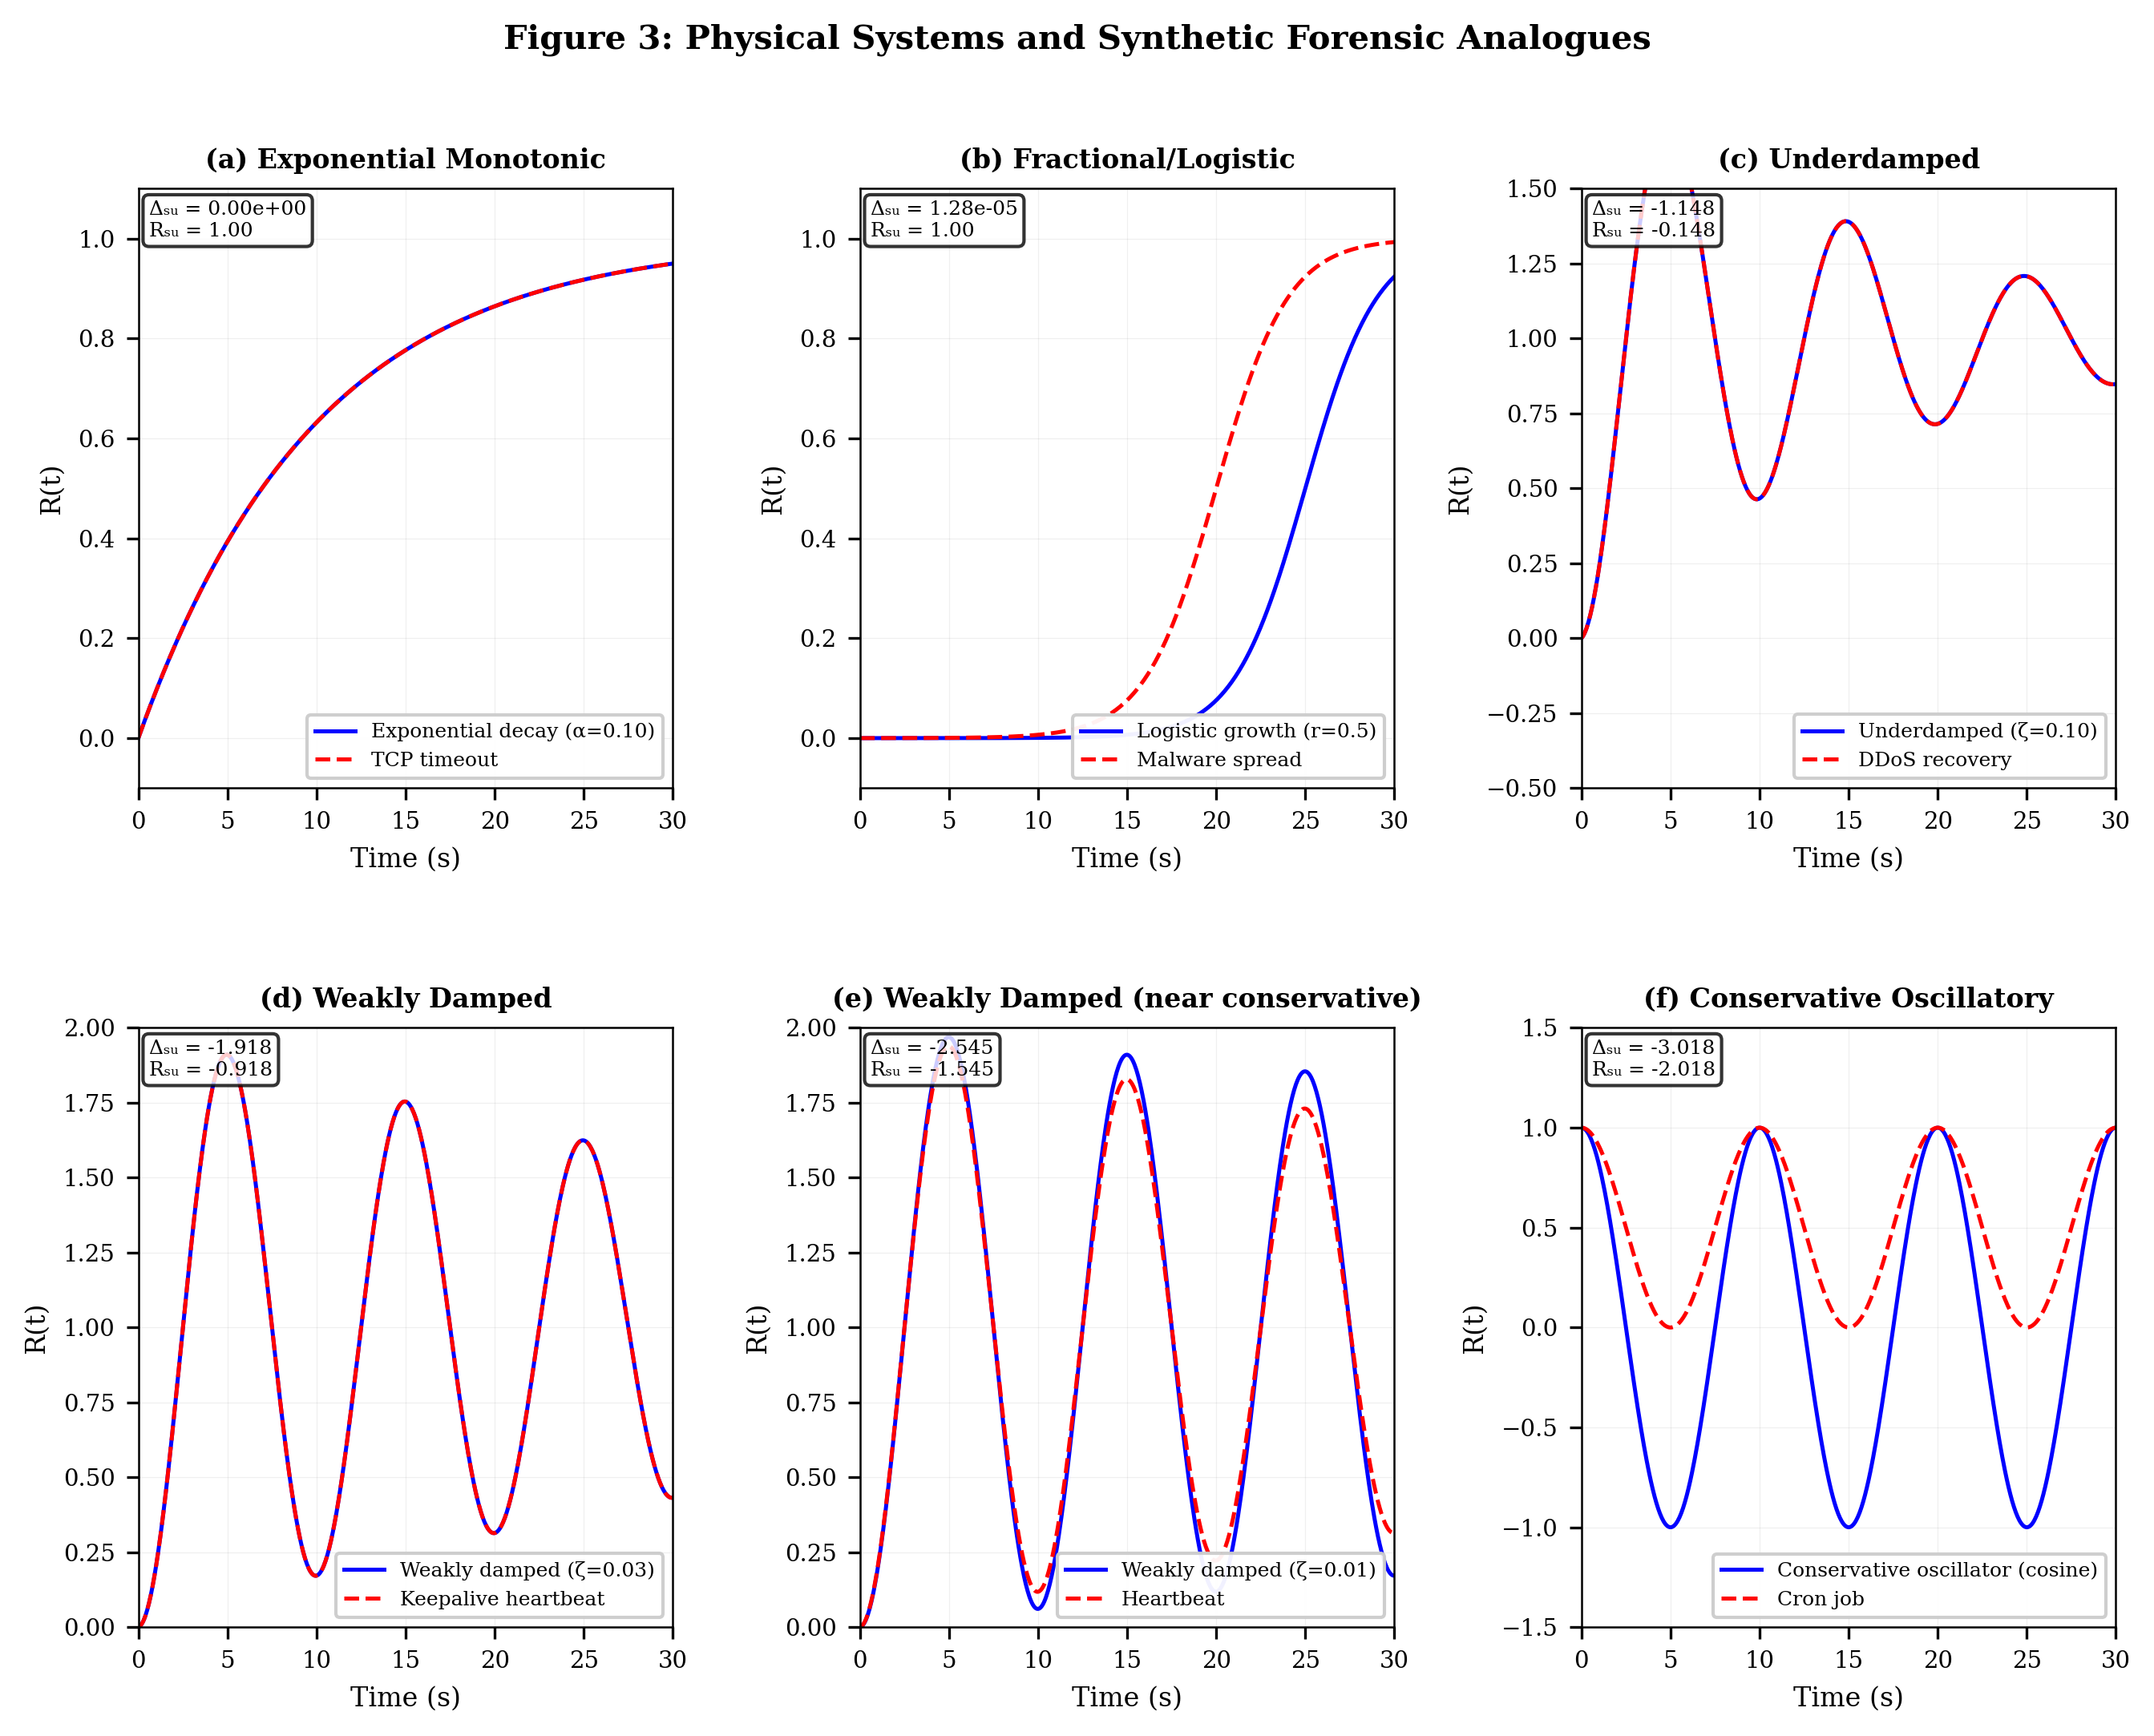


📊 Figure 2 - Verification from DataFrame:
   exp_0.10             Δ=  0.0000  R=  1.0000
   tcp_timeout          Δ=  0.0000  R=  1.0000

   logistic_r0.5        Δ=  0.0000  R=  1.0000
   malware_spread       Δ=  0.0000  R=  1.0000

   underdamped_0.10     Δ= -1.1477  R= -0.1477
   ddos_recovery        Δ= -1.1477  R= -0.1477

   underdamped_0.03     Δ= -1.9182  R= -0.9182
   keepalive            Δ= -1.9182  R= -0.9182

   underdamped_0.01     Δ= -2.5449  R= -1.5449
   heartbeat            Δ= -2.1888  R= -1.1888

   pure_cosine          Δ= -3.0182  R= -2.0182
   cron_job             Δ= -3.0182  R= -2.0182



In [8]:
"""
Figure 2: Physical vs Forensic Time Series Comparison
Six pairs of physical systems and their forensic analogs.
Uses existing regimes_dict and t from your compute_regime_signatures() workflow.
"""

import numpy as np
import matplotlib.pyplot as plt

def figure_2_physical_forensic(regimes_dict, t, df=None, save_path='figure_2.pdf', show_plot=True):
    """
    Figure 2: Side-by-side comparison of physical systems and forensic analogs.
    
    Parameters
    ----------
    regimes_dict : dict
        Dictionary of {regime_name: response_array} from your simulation
    t : array
        Time vector
    df : DataFrame, optional
        DataFrame from compute_regime_signatures() - used for verification
    save_path : str
        Output file path
    show_plot : bool
        Display the plot interactively
    """
    
    # IEEE publication style
    plt.rcParams.update({
        'font.size': 8,
        'font.family': 'serif',
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'legend.fontsize': 6.5,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'lines.linewidth': 1.0,
        'axes.linewidth': 0.6
    })
    
    # Create figure with 2 rows, 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(9, 7))
    axes = axes.flatten()
    
    # ------------------------------------------------------------------------
    # PAIR 1: Exponential Decay / TCP Timeout
    # ------------------------------------------------------------------------
    ax = axes[0]
    
    physical = 'exp_0.10'
    forensic = 'tcp_timeout'
    
    if physical in regimes_dict and forensic in regimes_dict:
        ax.plot(t, regimes_dict[physical], 'b-', linewidth=1.2, 
               label=f'Exponential decay (α=0.10)')
        ax.plot(t, regimes_dict[forensic], 'r--', linewidth=1.2, 
               label='TCP timeout')
        
        # Add Δₛᵤ and Rₛᵤ from dataframe if available
        if df is not None and physical in df.index:
            delta = df.loc[physical, 'Delta_su']
            rsu = df.loc[physical, 'R_su']
            ax.text(0.02, 0.98, f'Δₛᵤ = {delta:.2e}\nRₛᵤ = {rsu:.2f}', 
                   transform=ax.transAxes, fontsize=6, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('R(t)')
    ax.set_title('(a) Exponential Monotonic', fontweight='bold', fontsize=8)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=6)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.3)
    ax.set_xlim(0, 30)
    ax.set_ylim(-0.1, 1.1)
    
    # ------------------------------------------------------------------------
    # PAIR 2: Logistic Growth / Malware Spread
    # ------------------------------------------------------------------------
    ax = axes[1]
    
    physical = 'logistic_r0.5'
    forensic = 'malware_spread'
    
    if physical in regimes_dict and forensic in regimes_dict:
        ax.plot(t, regimes_dict[physical], 'b-', linewidth=1.2, 
               label=f'Logistic growth (r=0.5)')
        ax.plot(t, regimes_dict[forensic], 'r--', linewidth=1.2, 
               label='Malware spread')
        
        if df is not None and physical in df.index:
            delta = df.loc[physical, 'Delta_su']
            rsu = df.loc[physical, 'R_su']
            ax.text(0.02, 0.98, f'Δₛᵤ = {delta:.2e}\nRₛᵤ = {rsu:.2f}', 
                   transform=ax.transAxes, fontsize=6, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('R(t)')
    ax.set_title('(b) Fractional/Logistic', fontweight='bold', fontsize=8)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=6)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.3)
    ax.set_xlim(0, 30)
    ax.set_ylim(-0.1, 1.1)
    
    # ------------------------------------------------------------------------
    # PAIR 3: Underdamped (ζ=0.10) / DDoS Recovery
    # ------------------------------------------------------------------------
    ax = axes[2]
    
    physical = 'underdamped_0.10'
    forensic = 'ddos_recovery'
    
    if physical in regimes_dict and forensic in regimes_dict:
        ax.plot(t, regimes_dict[physical], 'b-', linewidth=1.2, 
               label=f'Underdamped (ζ=0.10)')
        ax.plot(t, regimes_dict[forensic], 'r--', linewidth=1.2, 
               label='DDoS recovery')
        
        if df is not None and physical in df.index:
            delta = df.loc[physical, 'Delta_su']
            rsu = df.loc[physical, 'R_su']
            ax.text(0.02, 0.98, f'Δₛᵤ = {delta:.3f}\nRₛᵤ = {rsu:.3f}', 
                   transform=ax.transAxes, fontsize=6, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('R(t)')
    ax.set_title('(c) Underdamped', fontweight='bold', fontsize=8)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=6)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.3)
    ax.set_xlim(0, 30)
    ax.set_ylim(-0.5, 1.5)
    
    # ------------------------------------------------------------------------
    # PAIR 4: Weakly Damped (ζ=0.03) / Keepalive Heartbeat
    # ------------------------------------------------------------------------
    ax = axes[3]
    
    physical = 'underdamped_0.03'
    forensic = 'keepalive'
    
    if physical in regimes_dict and forensic in regimes_dict:
        ax.plot(t, regimes_dict[physical], 'b-', linewidth=1.2, 
               label=f'Weakly damped (ζ=0.03)')
        ax.plot(t, regimes_dict[forensic], 'r--', linewidth=1.2, 
               label='Keepalive heartbeat')
        
        if df is not None and physical in df.index:
            delta = df.loc[physical, 'Delta_su']
            rsu = df.loc[physical, 'R_su']
            ax.text(0.02, 0.98, f'Δₛᵤ = {delta:.3f}\nRₛᵤ = {rsu:.3f}', 
                   transform=ax.transAxes, fontsize=6, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('R(t)')
    ax.set_title('(d) Weakly Damped', fontweight='bold', fontsize=8)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=6)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.3)
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 2)
    
    # ------------------------------------------------------------------------
    # PAIR 5: Weakly Damped (ζ=0.01) / Heartbeat
    # ------------------------------------------------------------------------
    ax = axes[4]
    
    physical = 'underdamped_0.01'
    forensic = 'heartbeat'
    
    if physical in regimes_dict and forensic in regimes_dict:
        ax.plot(t, regimes_dict[physical], 'b-', linewidth=1.2, 
               label=f'Weakly damped (ζ=0.01)')
        ax.plot(t, regimes_dict[forensic], 'r--', linewidth=1.2, 
               label='Heartbeat')
        
        if df is not None and physical in df.index:
            delta = df.loc[physical, 'Delta_su']
            rsu = df.loc[physical, 'R_su']
            ax.text(0.02, 0.98, f'Δₛᵤ = {delta:.3f}\nRₛᵤ = {rsu:.3f}', 
                   transform=ax.transAxes, fontsize=6, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('R(t)')
    ax.set_title('(e) Weakly Damped (near conservative)', fontweight='bold', fontsize=8)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=6)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.3)
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 2)
    
    # ------------------------------------------------------------------------
    # PAIR 6: Conservative Cosine / Cron Job
    # ------------------------------------------------------------------------
    ax = axes[5]
    
    physical = 'pure_cosine'
    forensic = 'cron_job'
    
    if physical in regimes_dict and forensic in regimes_dict:
        ax.plot(t, regimes_dict[physical], 'b-', linewidth=1.2, 
               label='Conservative oscillator (cosine)')
        ax.plot(t, regimes_dict[forensic], 'r--', linewidth=1.2, 
               label='Cron job')
        
        if df is not None and physical in df.index:
            delta = df.loc[physical, 'Delta_su']
            rsu = df.loc[physical, 'R_su']
            ax.text(0.02, 0.98, f'Δₛᵤ = {delta:.3f}\nRₛᵤ = {rsu:.3f}', 
                   transform=ax.transAxes, fontsize=6, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('R(t)')
    ax.set_title('(f) Conservative Oscillatory', fontweight='bold', fontsize=8)
    ax.legend(loc='lower right', frameon=True, framealpha=0.95, fontsize=6)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.3)
    ax.set_xlim(0, 30)
    ax.set_ylim(-1.5, 1.5)
    
    # ------------------------------------------------------------------------
    # Overall title
    # ------------------------------------------------------------------------
    fig.suptitle('Figure 3: Physical Systems and Synthetic Forensic Analogues', 
                fontsize=10, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.35)
    
    # Save
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figure 2 saved to: {save_path}")
    
    # Show
    if show_plot:
        plt.show()
    else:
        plt.close()
    
    # Print verification from dataframe
    if df is not None:
        print("\n📊 Figure 2 - Verification from DataFrame:")
        pairs = [
            ('exp_0.10', 'tcp_timeout'),
            ('logistic_r0.5', 'malware_spread'),
            ('underdamped_0.10', 'ddos_recovery'),
            ('underdamped_0.03', 'keepalive'),
            ('underdamped_0.01', 'heartbeat'),
            ('pure_cosine', 'cron_job')
        ]
        
        for phys, foren in pairs:
            if phys in df.index and foren in df.index:
                print(f"   {phys:20} Δ={df.loc[phys, 'Delta_su']:8.4f}  R={df.loc[phys, 'R_su']:8.4f}")
                print(f"   {foren:20} Δ={df.loc[foren, 'Delta_su']:8.4f}  R={df.loc[foren, 'R_su']:8.4f}")
                print()
    
    return fig, axes


# ----------------------------------------------------------------------------
# USAGE - WORKS WITH YOUR EXISTING WORKFLOW
# ----------------------------------------------------------------------------

fig2, axes2 = figure_2_physical_forensic(regimes, t, df, save_path='figure_2.pdf', show_plot=True)


In [9]:
df.columns

Index(['tau_s', 'tau_u', 'Delta_su', 'R_su'], dtype='object')

### Figure3

✓ Figure 3 saved to: figure_3.pdf


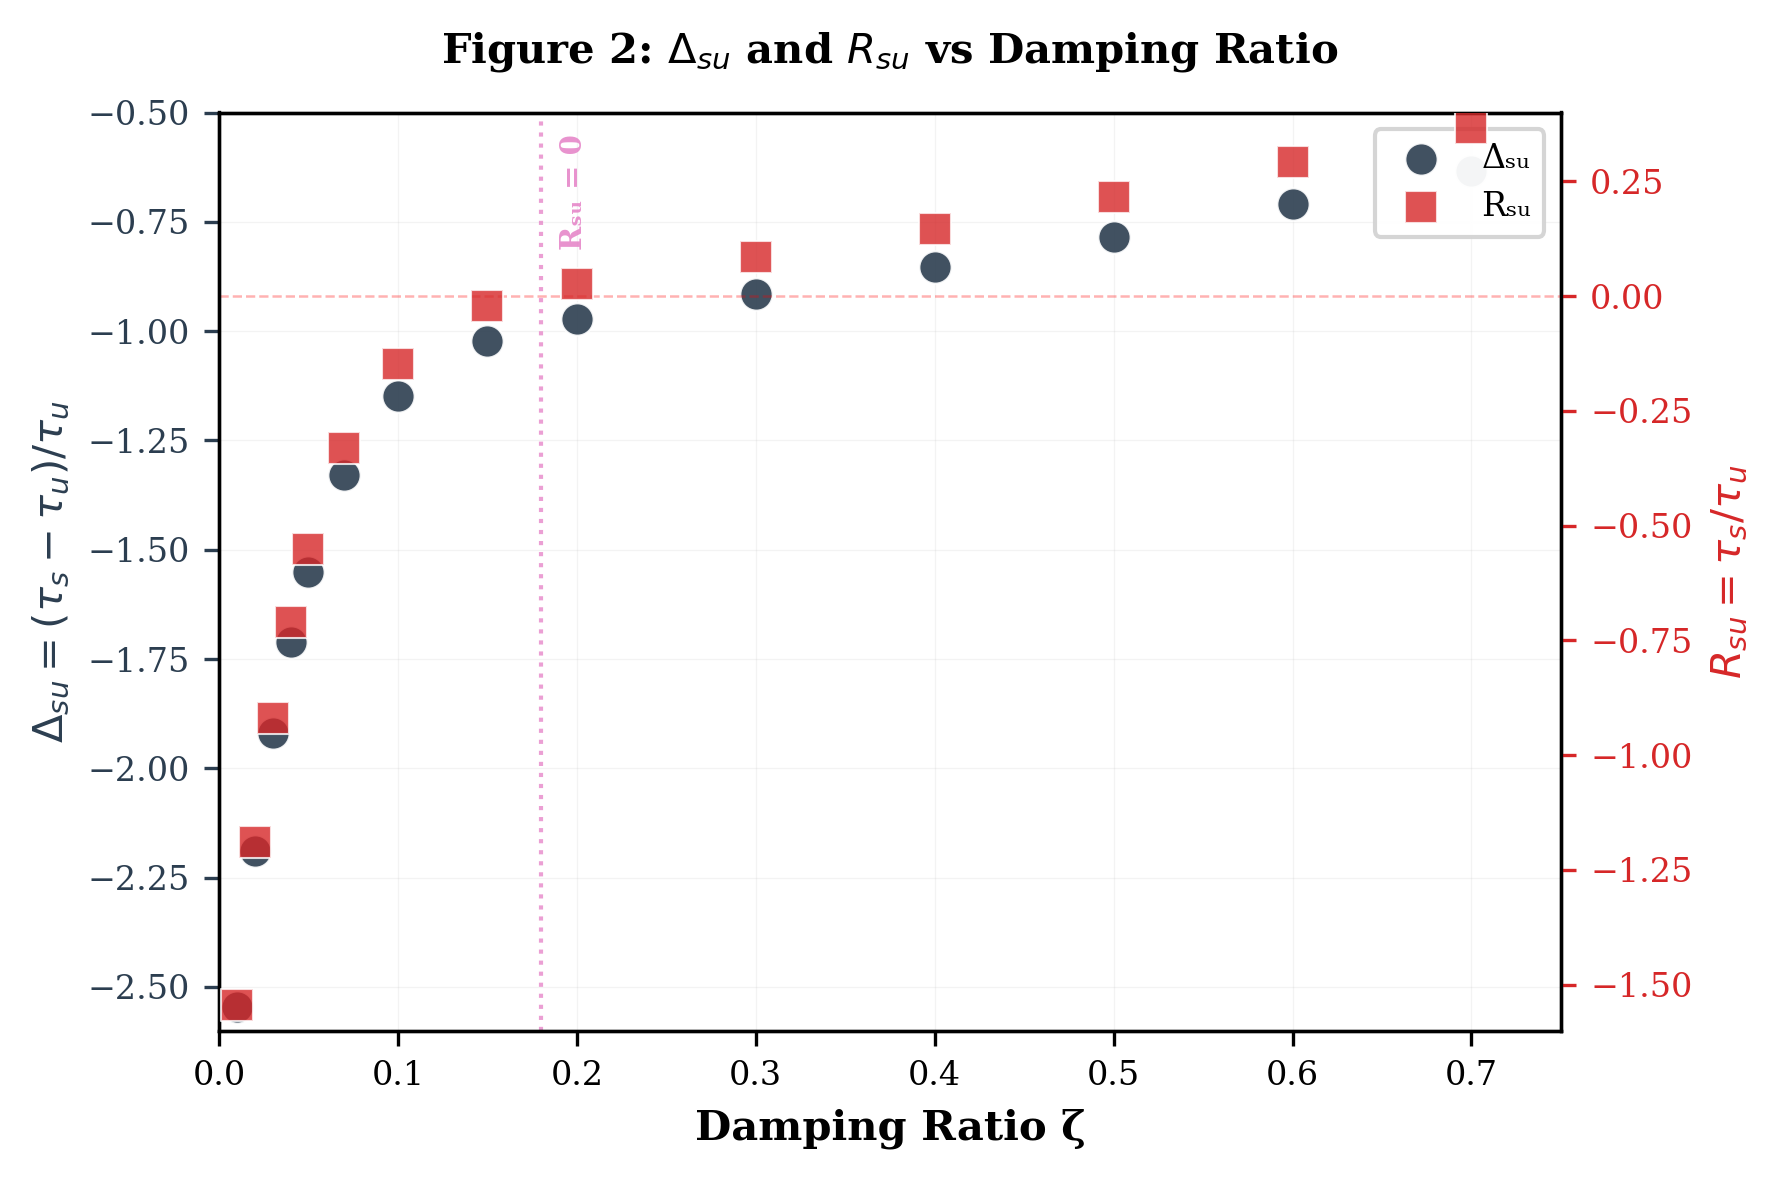


📊 Figure 2 - Underdamped systems (data points only):
   ζ     Δₛᵤ      Rₛᵤ
   ──────────────────────
   0.70   -0.6327    0.3673
   0.60   -0.7089    0.2911
   0.50   -0.7839    0.2161
   0.40   -0.8538    0.1462
   0.30   -0.9149    0.0851
   0.20   -0.9725    0.0275
   0.15   -1.0217   -0.0217
   0.10   -1.1477   -0.1477
   0.07   -1.3300   -0.3300
   0.05   -1.5508   -0.5508
   0.04   -1.7108   -0.7108
   0.03   -1.9182   -0.9182
   0.02   -2.1888   -1.1888
   0.01   -2.5449   -1.5449

   Rₛᵤ = 0 crossover at ζ = 0.15


In [10]:
"""
Figure 3: Δₛᵤ and Rₛᵤ vs Damping Ratio ζ for Underdamped Oscillators.
Pure data points only - no fitted trends.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def figure_3_delta_vs_zeta(df, save_path='figure_3.pdf', show_plot=True):
    """
    Figure 3: Δₛᵤ and Rₛᵤ as functions of damping ratio ζ.
    Pure data points - no fitted curves.
    
    Parameters
    ----------
    df : DataFrame
        DataFrame from compute_regime_signatures() with underdamped_* entries
    save_path : str
        Output file path
    show_plot : bool
        Display the plot interactively
    """
    
    # IEEE publication style
    plt.rcParams.update({
        'font.size': 9,
        'font.family': 'serif',
        'axes.labelsize': 9,
        'axes.titlesize': 9,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'lines.linewidth': 1.2,
        'axes.linewidth': 0.8
    })
    
    fig, ax1 = plt.subplots(figsize=(6, 4))
    
    # ------------------------------------------------------------------------
    # EXTRACT UNDERDAMPED SYSTEMS (0.01 ≤ ζ ≤ 0.70)
    # ------------------------------------------------------------------------
    
    zeta_values = [0.70, 0.60, 0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.07, 0.05, 0.04, 0.03, 0.02, 0.01]
    delta_values = []
    rsu_values = []
    
    for zeta in zeta_values:
        name = f'underdamped_{zeta:.2f}'
        if name in df.index:
            delta_values.append(df.loc[name, 'Delta_su'])
            rsu_values.append(df.loc[name, 'R_su'])
        else:
            delta_values.append(np.nan)
            rsu_values.append(np.nan)
    
    # Remove NaNs
    valid = ~np.isnan(delta_values)
    zeta_valid = np.array(zeta_values)[valid]
    delta_valid = np.array(delta_values)[valid]
    rsu_valid = np.array(rsu_values)[valid]
    
    # ------------------------------------------------------------------------
    # PRIMARY AXIS: Δₛᵤ vs ζ - PURE DATA POINTS ONLY
    # ------------------------------------------------------------------------
    
    ax1.scatter(zeta_valid, delta_valid, c='#2c3e50', marker='o', s=60, alpha=0.9,
               edgecolors='white', linewidth=0.5, zorder=5, label='Δₛᵤ')
    
    # ------------------------------------------------------------------------
    # REFERENCE LINES
    # ------------------------------------------------------------------------
    
    # Zero line
    ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.6, alpha=0.5, zorder=1)
    
    # Crossover at ζ ≈ 0.18 (where Rₛᵤ = 0)
    ax1.axvline(x=0.18, color='#e377c2', linestyle=':', linewidth=1.0, alpha=0.7, zorder=2)
    ax1.text(0.19, -0.8, 'Rₛᵤ = 0', rotation=90, fontsize=7, 
            alpha=0.8, color='#e377c2', fontweight='bold')
    
    # ------------------------------------------------------------------------
    # SECONDARY AXIS: Rₛᵤ vs ζ - PURE DATA POINTS ONLY
    # ------------------------------------------------------------------------
    
    ax2 = ax1.twinx()
    ax2.scatter(zeta_valid, rsu_valid, c='#d62728', marker='s', s=60, alpha=0.8,
               edgecolors='white', linewidth=0.5, zorder=6, label='Rₛᵤ')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.6, alpha=0.3, zorder=1)
    
    # ------------------------------------------------------------------------
    # LABELS AND FORMATTING
    # ------------------------------------------------------------------------
    
    ax1.set_xlabel('Damping Ratio ζ', fontsize=10, fontweight='bold')
    ax1.set_ylabel('$\Delta_{su} = (\\tau_s - \\tau_u)/\\tau_u$', fontsize=10, fontweight='bold', color='#2c3e50')
    ax2.set_ylabel('$R_{su} = \\tau_s/\\tau_u$', fontsize=10, fontweight='bold', color='#d62728')
    
    ax1.set_title('Figure 2: $\Delta_{su}$ and $R_{su}$ vs Damping Ratio', 
                 fontsize=10, fontweight='bold', pad=12)
    
    # Set axis limits
    ax1.set_xlim(0, 0.75)
    ax1.set_ylim(-2.6, -0.5)
    ax2.set_ylim(-1.6, 0.4)
    
    # Grid
    ax1.grid(True, alpha=0.15, linestyle='-', linewidth=0.3, zorder=0)
    
    # Legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', 
              frameon=True, framealpha=0.95, edgecolor='lightgray', fontsize=8)
    
    # Color the y-axis labels
    ax1.yaxis.label.set_color('#2c3e50')
    ax2.yaxis.label.set_color('#d62728')
    ax1.tick_params(axis='y', colors='#2c3e50')
    ax2.tick_params(axis='y', colors='#d62728')
    
    plt.tight_layout()
    
    # Save
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figure 3 saved to: {save_path}")
    
    # Show
    if show_plot:
        plt.show()
    else:
        plt.close()
    
    # Print verification
    print("\n📊 Figure 2 - Underdamped systems (data points only):")
    print("   ζ     Δₛᵤ      Rₛᵤ")
    print("   ──────────────────────")
    for zeta, delta, rsu in zip(zeta_valid, delta_valid, rsu_valid):
        print(f"   {zeta:.2f}  {delta:8.4f}  {rsu:8.4f}")
    
    # Find crossover
    crossover_idx = np.where(np.array(rsu_values) <= 0)[0]
    if len(crossover_idx) > 0:
        zeta_cross = zeta_values[crossover_idx[0]]
        print(f"\n   Rₛᵤ = 0 crossover at ζ = {zeta_cross:.2f}")
    
    return fig, (ax1, ax2)


# ----------------------------------------------------------------------------
# USAGE
# ----------------------------------------------------------------------------

fig3, axes3 = figure_3_delta_vs_zeta(df, save_path='figure_3.pdf', show_plot=True)


# Application to Forensic Data real: The user should provide the path to the Forensic data, and paste the zipped file path

# Forensic Data real..... Data Source:    https://ro.ecu.edu.au/datasets/151/

## Download this zip file......APT-20251006T071928Z-1-001.zip (1683687 kB)

In [13]:
import numpy as np
import pandas as pd
from scapy.all import rdpcap
from QSignature import compute_all
import os
import zipfile
import tempfile
import shutil

# Path to your main zip
main_zip_path = 'paste your path here/Asaf data.zip'
extract_dir = './extracted_data/'
os.makedirs(extract_dir, exist_ok=True)

print("="*60)
print("EXTRACTING MAIN ZIP...")
print("="*60)

# Extract main zip
with zipfile.ZipFile(main_zip_path, 'r') as main_zip:
    main_zip.extractall(extract_dir)
print(f"Main zip extracted to {extract_dir}")

# Function to recursively find and extract nested zips
def extract_nested_zips(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.zip'):
                zip_path = os.path.join(root, file)
                print(f"\nFound nested zip: {zip_path}")
                
                # Create extraction folder next to the zip
                extract_folder = os.path.join(root, file.replace('.zip', '_extracted'))
                os.makedirs(extract_folder, exist_ok=True)
                
                # Extract nested zip
                try:
                    with zipfile.ZipFile(zip_path, 'r') as nested_zip:
                        nested_zip.extractall(extract_folder)
                    print(f"  Extracted to {extract_folder}")
                except Exception as e:
                    print(f"  Error extracting {zip_path}: {e}")

# Extract all nested zips
print("\n" + "="*60)
print("EXTRACTING NESTED ZIPS...")
print("="*60)
extract_nested_zips(extract_dir)

# Modified analyze function with type conversion
def analyze_pcap(pcap_path, label):
    print(f"\nAnalyzing {os.path.basename(pcap_path)}...")
    
    try:
        # Skip macOS metadata files
        if '._' in os.path.basename(pcap_path):
            print(f"  Skipping macOS metadata file")
            return None
        
        # Read packets
        packets = rdpcap(pcap_path)
        print(f"  Loaded {len(packets)} packets")
        
        if len(packets) < 10:
            print(f"  Skipping - too few packets")
            return None
        
        # Extract packet timestamps
        timestamps = np.array([float(p.time) for p in packets])  # Force to float
        
        # Normalize time to start at 0
        t = timestamps - timestamps[0]
        
        # Create cumulative packet count (convert to float to avoid int64 issues)
        packet_count = np.arange(len(t), dtype=float)
        
        # Ensure t is float64
        t = t.astype(np.float64)
        
        # Compute signature
        try:
            sig = compute_all(t, packet_count)
            
            # Convert any numpy types to Python native types
            result = {
                'file': os.path.basename(pcap_path),
                'label': label,
                'Delta_su': float(sig['Delta_su']) if sig['Delta_su'] is not None else np.nan,
                'R_su': float(sig['R_su']) if sig['R_su'] is not None else np.nan,
                'tau_s': float(sig['tau_s']) if sig['tau_s'] is not None else np.nan,
                'tau_u': float(sig['tau_u']) if sig['tau_u'] is not None else np.nan,
                'num_packets': len(packets),
                'duration': float(t[-1])
            }
            
            # Print result
            print(f"  Δ_su = {result['Delta_su']:.6f}, R_su = {result['R_su']:.6f}")
            return result
            
        except Exception as e:
            print(f"  Error computing signature: {e}")
            # Try with alternative approach - use interarrival times
            try:
                print(f"  Trying alternative method with interarrival times...")
                interarrival = np.diff(t, dtype=np.float64)
                cum_interarrival = np.cumsum(interarrival)
                t_alt = np.arange(len(interarrival), dtype=np.float64)
                
                sig = compute_all(t_alt, cum_interarrival)
                
                result = {
                    'file': os.path.basename(pcap_path),
                    'label': label,
                    'Delta_su': float(sig['Delta_su']) if sig['Delta_su'] is not None else np.nan,
                    'R_su': float(sig['R_su']) if sig['R_su'] is not None else np.nan,
                    'tau_s': float(sig['tau_s']) if sig['tau_s'] is not None else np.nan,
                    'tau_u': float(sig['tau_u']) if sig['tau_u'] is not None else np.nan,
                    'num_packets': len(packets),
                    'duration': float(t[-1])
                }
                print(f"  Alternative: Δ_su = {result['Delta_su']:.6f}, R_su = {result['R_su']:.6f}")
                return result
            except Exception as e2:
                print(f"  Alternative also failed: {e2}")
                return None
            
    except Exception as e:
        print(f"  Error reading pcap: {e}")
        return None

# Find and analyze all PCAPs
print("\n" + "="*60)
print("SEARCHING FOR PCAP FILES...")
print("="*60)

results = []
pcap_count = 0

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(('.pcap', '.pcapng', '.cap')) and not file.startswith('._'):
            pcap_count += 1
            full_path = os.path.join(root, file)
            
            # Determine label from folder structure
            path_lower = full_path.lower()
            if 'apt' in path_lower or 'turla' in path_lower or 'lazarus' in path_lower:
                label = 'APT'
            elif 'rusty' in path_lower:
                label = 'RustyStealer'
            else:
                label = 'Unknown'
            
            # Analyze a sample (every 5th file for now)
            if pcap_count % 5 == 1:  # Analyze ~20% of files
                print(f"\n[{pcap_count}] Found: {os.path.relpath(full_path, extract_dir)}")
                result = analyze_pcap(full_path, label)
                if result:
                    results.append(result)

print(f"\nTotal PCAP files found: {pcap_count}")

# Create results table
if results:
    df = pd.DataFrame(results)
    
    print("\n" + "="*60)
    print("RESULTS SUMMARY")
    print("="*60)
    print(df[['label', 'Delta_su', 'R_su', 'num_packets']].to_string())
    
    # Summary statistics by label
    print("\n" + "="*60)
    print("SUMMARY BY LABEL:")
    print("="*60)
    summary = df.groupby('label').agg({
        'Delta_su': ['mean', 'std', 'count'],
        'R_su': ['mean', 'std'],
        'num_packets': ['mean', 'sum']
    }).round(6)
    print(summary)
    
    # Save to CSV
    df.to_csv('forensic_results.csv', index=False)
    print("\nResults saved to forensic_results.csv")
    
    # Check against expected regimes
    print("\n" + "="*60)
    print("REGIME CHECK:")
    print("="*60)
    
    expected = {
        'APT': {'Delta_su': (-1.15, -1.13), 'R_su': (-0.15, -0.13), 'regime': 'Weakly Damped'},
        'RustyStealer': {'Delta_su': (0, 1e-4), 'R_su': (1.000001, 1.0001), 'regime': 'Fractional/Logistic'},
    }
    
    for label in df['label'].unique():
        subset = df[df['label'] == label]
        if len(subset) > 0:
            mean_delta = subset['Delta_su'].mean()
            mean_rsu = subset['R_su'].mean()
            
            print(f"\n{label} ({len(subset)} samples):")
            print(f"  Δ_su = {mean_delta:.6f} ± {subset['Delta_su'].std():.6f}")
            print(f"  R_su = {mean_rsu:.6f} ± {subset['R_su'].std():.6f}")
            
            if label in expected:
                exp = expected[label]
                delta_match = exp['Delta_su'][0] <= mean_delta <= exp['Delta_su'][1]
                rsu_match = exp['R_su'][0] <= mean_rsu <= exp['R_su'][1]
                
                print(f"  Expected {exp['regime']}: {delta_match and rsu_match}")
else:
    print("\nNo results found. Check if PCAP files exist in the extracted folders.")
    
    # Debug: List all extracted files
    print("\n" + "="*60)
    print("DEBUG: First 20 extracted files:")
    print("="*60)
    file_count = 0
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if file_count < 20:
                print(os.path.join(root, file))
                file_count += 1
            else:
                break

EXTRACTING MAIN ZIP...
Main zip extracted to ./extracted_data/

EXTRACTING NESTED ZIPS...

Found nested zip: ./extracted_data/APT/pcaps.zip
  Extracted to ./extracted_data/APT/pcaps_extracted

SEARCHING FOR PCAP FILES...

[1] Found: APT/pcaps_extracted/APT29/6057b19975818ff4487ee62d5341834c53ab80a507949a52422ab37c7c46b7a1.pcap

Analyzing 6057b19975818ff4487ee62d5341834c53ab80a507949a52422ab37c7c46b7a1.pcap...
  Loaded 13508 packets
  Error computing signature: 'R_su'
  Trying alternative method with interarrival times...
  Alternative also failed: diff() got an unexpected keyword argument 'dtype'

[6] Found: APT/pcaps_extracted/APT28/ee7cfc55a49b2e9825a393a94b0baad18ef5bfced67531382e572ef8a9ecda4b.pcap

Analyzing ee7cfc55a49b2e9825a393a94b0baad18ef5bfced67531382e572ef8a9ecda4b.pcap...
  Loaded 21369 packets
  Error computing signature: 'R_su'
  Trying alternative method with interarrival times...
  Alternative also failed: diff() got an unexpected keyword argument 'dtype'

[11] Found: 

# Computing Delta_taus, plot Q space and save 

# Plot and save in file directory

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scapy.all import rdpcap
from QSignature import compute_all
import os
from datetime import datetime
import json

# Set figure size
plt.rcParams['figure.figsize'] = [12, 4]  # Adjusted for 2 panels

# Create output directory
output_dir = 'forensic_analysis_results'
os.makedirs(output_dir, exist_ok=True)
plots_dir = os.path.join(output_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)
timeseries_dir = os.path.join(output_dir, 'timeseries')
os.makedirs(timeseries_dir, exist_ok=True)

def analyze_pcap_comprehensive(pcap_path, label, sample_idx):
    print(f"\nAnalyzing {os.path.basename(pcap_path)}...")
    
    try:
        if '._' in os.path.basename(pcap_path):
            return None
        
        # Read packets
        packets = rdpcap(pcap_path)
        print(f"  Loaded {len(packets)} packets")
        
        if len(packets) < 100:
            print(f"  Skipping - too few packets")
            return None
        
        # Extract timestamps
        timestamps = np.array([float(p.time) for p in packets])
        t = timestamps - timestamps[0]
        
        # === CUMULATIVE ANALYSIS (original method) ===
        R_cumulative = np.arange(len(t), dtype=float)
        
        # Compute signatures on cumulative
        try:
            sig_cum = compute_all(t, R_cumulative)
            tau_s_cum = float(sig_cum['tau_s'])
            tau_u_cum = float(sig_cum['tau_u'])
            Delta_su_cum = float(sig_cum['Delta_su'])
            R_su_cum = tau_s_cum / tau_u_cum if tau_u_cum != 0 else np.nan
        except Exception as e:
            print(f"  Error on cumulative: {e}")
            tau_s_cum, tau_u_cum, Delta_su_cum, R_su_cum = np.nan, np.nan, np.nan, np.nan
        
        # === RATE-BASED ANALYSIS (normalized) ===
        # Create time bins
        max_time = t[-1]
        bin_size = max(0.1, max_time / 100)
        bins = np.arange(0, max_time + bin_size, bin_size)
        
        # Count packets per bin
        packet_rate, bin_edges = np.histogram(t, bins=bins)
        t_rate = bin_edges[:-1]
        
        # Normalize rate
        if np.max(packet_rate) > 0 and len(packet_rate) > 10:
            R_rate_norm = packet_rate / np.max(packet_rate)
            t_rate_norm = t_rate / t_rate[-1] if t_rate[-1] > 0 else t_rate
            
            try:
                sig_rate = compute_all(t_rate_norm, R_rate_norm)
                tau_s_rate = float(sig_rate['tau_s'])
                tau_u_rate = float(sig_rate['tau_u'])
                Delta_su_rate = float(sig_rate['Delta_su'])
                R_su_rate = tau_s_rate / tau_u_rate if tau_u_rate != 0 else np.nan
            except Exception as e:
                print(f"  Error on rate: {e}")
                tau_s_rate, tau_u_rate, Delta_su_rate, R_su_rate = np.nan, np.nan, np.nan, np.nan
        else:
            tau_s_rate, tau_u_rate, Delta_su_rate, R_su_rate = np.nan, np.nan, np.nan, np.nan
        
        # === CREATE PLOT (2 panels) ===
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Panel 1: Cumulative with annotations
        axes[0].plot(t, R_cumulative, 'b-', linewidth=1.5)
        axes[0].axvline(x=tau_s_cum, color='red', linestyle='--', alpha=0.7, 
                       label=f'τ_s={tau_s_cum:.2f}')
        axes[0].axvline(x=tau_u_cum, color='orange', linestyle='--', alpha=0.7, 
                       label=f'τ_u={tau_u_cum:.2f}')
        axes[0].set_title(f'{label} - Cumulative Packets\nΔ_su={Delta_su_cum:.4f}, R_su={R_su_cum:.4f}', 
                         fontsize=11, fontweight='bold')
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Packet Count')
        axes[0].legend(fontsize=9)
        axes[0].grid(True, alpha=0.3)
        
        # Add text box with values
        textstr = f'CUMULATIVE:\nΔ_su = {Delta_su_cum:.6f}\nR_su = {R_su_cum:.6f}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes, fontsize=9,
                    verticalalignment='top', bbox=props)
        
        # Panel 2: Normalized Rate with annotations
        if not np.isnan(Delta_su_rate):
            axes[1].plot(t_rate_norm, R_rate_norm, 'g-', linewidth=1.5)
            axes[1].axvline(x=tau_s_rate, color='red', linestyle='--', alpha=0.7, 
                           label=f'τ_s={tau_s_rate:.3f}')
            axes[1].axvline(x=tau_u_rate, color='orange', linestyle='--', alpha=0.7, 
                           label=f'τ_u={tau_u_rate:.3f}')
            axes[1].set_title(f'{label} - Normalized Packet Rate\nΔ_su={Delta_su_rate:.4f}, R_su={R_su_rate:.4f}', 
                             fontsize=11, fontweight='bold')
            
            # Add text box with values
            textstr = f'NORMALIZED RATE:\nΔ_su = {Delta_su_rate:.6f}\nR_su = {R_su_rate:.6f}'
            props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
            axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes, fontsize=9,
                        verticalalignment='top', bbox=props)
        else:
            axes[1].text(0.5, 0.5, 'Rate analysis failed\n(insufficient data)', 
                       ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
            axes[1].set_title(f'{label} - Rate Analysis Failed', fontsize=11, fontweight='bold')
        
        axes[1].set_xlabel('Normalized Time')
        axes[1].set_ylabel('Normalized Rate')
        if not np.isnan(Delta_su_rate):
            axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'{sample_idx:03d}_{label}_{os.path.basename(pcap_path)[:20]}.png'
        plot_path = os.path.join(plots_dir, plot_filename)
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        # === SAVE TIME SERIES DATA ===
        # Create a dictionary with all time series data
        timeseries_data = {
            'metadata': {
                'file': os.path.basename(pcap_path),
                'label': label,
                'sample_idx': sample_idx,
                'num_packets': len(packets),
                'duration': float(t[-1]),
                'Delta_su_cumulative': Delta_su_cum,
                'R_su_cumulative': R_su_cum,
                'Delta_su_rate': Delta_su_rate,
                'R_su_rate': R_su_rate,
            },
            'cumulative': {
                'time': t.tolist(),
                'packet_count': R_cumulative.tolist()
            },
            'rate': {
                'time': t_rate.tolist(),
                'packet_rate': packet_rate.tolist(),
                'normalized_time': t_rate_norm.tolist() if not np.isnan(Delta_su_rate) else [],
                'normalized_rate': R_rate_norm.tolist() if not np.isnan(Delta_su_rate) else []
            }
        }
        
        # Save as JSON
        json_filename = f'{sample_idx:03d}_{label}_{os.path.basename(pcap_path)[:20]}.json'
        json_path = os.path.join(timeseries_dir, json_filename)
        with open(json_path, 'w') as f:
            json.dump(timeseries_data, f, indent=2)
        
        # Also save as CSV for easy viewing
        csv_filename = f'{sample_idx:03d}_{label}_{os.path.basename(pcap_path)[:20]}.csv'
        csv_path = os.path.join(timeseries_dir, csv_filename)
        
        # Create a DataFrame with all time series
        max_len = max(len(t), len(t_rate))
        df_timeseries = pd.DataFrame({
            'time_cumulative': pd.Series(t),
            'packet_count': pd.Series(R_cumulative),
            'time_rate': pd.Series(t_rate),
            'packet_rate': pd.Series(packet_rate),
        })
        df_timeseries.to_csv(csv_path, index=False)
        
        print(f"  → Cumulative: Δ_su={Delta_su_cum:.6f}, R_su={R_su_cum:.6f}")
        print(f"  → Rate: Δ_su={Delta_su_rate:.6f}, R_su={R_su_rate:.6f}")
        print(f"  → Plot saved: {plot_filename}")
        print(f"  → Timeseries saved: {csv_filename}")
        
        # Return comprehensive results
        return {
            # File info
            'file': os.path.basename(pcap_path),
            'full_path': pcap_path,
            'label': label,
            'sample_idx': sample_idx,
            
            # Cumulative signatures
            'Delta_su_cumulative': Delta_su_cum,
            'R_su_cumulative': R_su_cum,
            'tau_s_cumulative': tau_s_cum,
            'tau_u_cumulative': tau_u_cum,
            
            # Rate-based signatures
            'Delta_su_rate': Delta_su_rate,
            'R_su_rate': R_su_rate,
            'tau_s_rate': tau_s_rate,
            'tau_u_rate': tau_u_rate,
            
            # Packet statistics
            'num_packets': len(packets),
            'duration_seconds': float(t[-1]),
            'avg_packet_rate': len(packets) / t[-1] if t[-1] > 0 else 0,
            
            # Bin information
            'num_bins': len(packet_rate) if 'packet_rate' in locals() else 0,
            'bin_size_seconds': bin_size if 'bin_size' in locals() else 0,
            
            # File references
            'plot_file': plot_filename,
            'timeseries_csv': csv_filename,
            'timeseries_json': json_filename,
            
            # Timestamp
            'analysis_time': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
    except Exception as e:
        print(f"  Error: {e}")
        return None

# Main analysis
extract_dir = './extracted_data/'

print("\n" + "="*70)
print("FORENSIC DATA ANALYSIS WITH QSIGNATURE")
print("="*70)
print(f"Output directory: {output_dir}")
print(f"Plots directory: {plots_dir}")
print(f"Timeseries directory: {timeseries_dir}")
print("="*70)

results = []
pcap_count = 0
sample_idx = 0
max_samples = 20  # Analyze up to 20 PCAPs

categories = {
    'apt28': 'APT28',
    'apt29': 'APT29', 
    'lazarus': 'Lazarus',
    'rusty': 'RustyStealer',
    'turla': 'Turla'
}

# Walk through extracted files
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.pcap') and not file.startswith('._'):
            pcap_count += 1
            full_path = os.path.join(root, file)
            
            # Determine label
            path_lower = full_path.lower()
            label = 'Unknown'
            for key, value in categories.items():
                if key in path_lower:
                    label = value
                    break
            
            # Analyze samples
            if sample_idx < max_samples:
                sample_idx += 1
                print(f"\n[{sample_idx}/{max_samples}] Analyzing: {os.path.relpath(full_path, extract_dir)}")
                result = analyze_pcap_comprehensive(full_path, label, sample_idx)
                if result:
                    results.append(result)

print(f"\n{'='*70}")
print(f"ANALYSIS COMPLETE")
print(f"{'='*70}")
print(f"Total PCAP files found: {pcap_count}")
print(f"Successfully analyzed: {len(results)}")

# Save results to files
if results:
    # Create DataFrame
    df = pd.DataFrame(results)
    
    # 1. Save as CSV
    csv_path = os.path.join(output_dir, 'forensic_results.csv')
    df.to_csv(csv_path, index=False)
    print(f"\n✅ CSV saved: {csv_path}")
    
    # 2. Save as Excel
    try:
        excel_path = os.path.join(output_dir, 'forensic_results.xlsx')
        df.to_excel(excel_path, index=False)
        print(f"✅ Excel saved: {excel_path}")
    except:
        print("⚠️  Excel export failed (install openpyxl: pip install openpyxl)")
    
    # 3. Save summary text
    summary_path = os.path.join(output_dir, 'summary.txt')
    with open(summary_path, 'w') as f:
        f.write("="*70 + "\n")
        f.write("FORENSIC ANALYSIS SUMMARY\n")
        f.write("="*70 + "\n\n")
        
        f.write(f"Total samples analyzed: {len(df)}\n")
        f.write(f"Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        # Results by label
        f.write("RESULTS BY CATEGORY:\n")
        f.write("-"*50 + "\n")
        
        for label in df['label'].unique():
            subset = df[df['label'] == label]
            f.write(f"\n{label} ({len(subset)} samples):\n")
            
            # Cumulative
            delta_cum_mean = subset['Delta_su_cumulative'].mean()
            delta_cum_std = subset['Delta_su_cumulative'].std()
            rsu_cum_mean = subset['R_su_cumulative'].mean()
            
            f.write(f"  CUMULATIVE: Δ_su = {delta_cum_mean:.6f} ± {delta_cum_std:.6f}, R_su = {rsu_cum_mean:.6f}\n")
            
            # Rate
            delta_rate_mean = subset['Delta_su_rate'].mean()
            delta_rate_std = subset['Delta_su_rate'].std()
            rsu_rate_mean = subset['R_su_rate'].mean()
            rsu_rate_std = subset['R_su_rate'].std()
            
            f.write(f"  RATE: Δ_su = {delta_rate_mean:.6f} ± {delta_rate_std:.6f}, ")
            f.write(f"R_su = {rsu_rate_mean:.6f} ± {rsu_rate_std:.6f}\n")
            
            # Classify rate-based
            if -0.98 <= delta_rate_mean <= -0.63 and 0.02 <= rsu_rate_mean <= 0.37:
                regime = "Underdamped (ζ=0.20-0.70)"
            elif -2.55 <= delta_rate_mean <= -0.97 and -1.55 <= rsu_rate_mean <= -0.02:
                regime = "Weakly Damped (ζ=0.01-0.15)"
            elif -3.02 <= delta_rate_mean <= -1.00 and -2.02 <= rsu_rate_mean <= 0:
                regime = "Conservative Oscillatory"
            elif abs(delta_rate_mean) < 1e-5 and abs(rsu_rate_mean - 1.0) < 1e-5:
                regime = "Exponential Monotonic"
            elif 0 < delta_rate_mean < 0.005 and 1.0 < rsu_rate_mean < 1.005:
                regime = "Fractional/Logistic"
            else:
                regime = "Unknown/Mixed"
            
            f.write(f"  → Regime: {regime}\n")
        
        f.write("\n" + "="*70 + "\n")
    
    print(f"✅ Summary saved: {summary_path}")
    
    # 4. Print sample results
    print("\n" + "="*70)
    print("SAMPLE RESULTS (first 5):")
    print("="*70)
    print(df[['label', 'Delta_su_rate', 'R_su_rate', 'Delta_su_cumulative', 'R_su_cumulative']].head().to_string())
    
    # 5. Create a clean LaTeX table
    latex_path = os.path.join(output_dir, 'latex_table.txt')
    with open(latex_path, 'w') as f:
        f.write("\\begin{table}[h]\n")
        f.write("\\centering\n")
        f.write("\\caption{ECU-MALNETT forensic time series and their dynamical signatures}\n")
        f.write("\\label{tab:forensic_real}\n")
        f.write("\\renewcommand{\\arraystretch}{1.2}\n")
        f.write("\\setlength{\\tabcolsep}{3pt}\n")
        f.write("\\begin{tabular}{|l|c|c|c|}\n")
        f.write("\\hline\n")
        f.write("\\rowcolor{lightgray}\n")
        f.write("\\textbf{Forensic Signal} & \\textbf{$\\Delta_{su}$} & \\textbf{$R_{su}$} & \\textbf{Regime} \\\\\n")
        f.write("\\hline\n")
        
        for _, row in df.iterrows():
            delta = row['Delta_su_rate']
            rsu = row['R_su_rate']
            
            if pd.isna(delta) or pd.isna(rsu):
                regime = "N/A"
            elif -0.98 <= delta <= -0.63 and 0.02 <= rsu <= 0.37:
                regime = "Underdamped"
            elif -2.55 <= delta <= -0.97 and -1.55 <= rsu <= -0.02:
                regime = "Weakly Damped"
            elif -3.02 <= delta <= -1.00 and -2.02 <= rsu <= 0:
                regime = "Conservative"
            elif abs(delta) < 1e-5 and abs(rsu - 1.0) < 1e-5:
                regime = "Exponential"
            elif 0 < delta < 0.005 and 1.0 < rsu < 1.005:
                regime = "Fractional/Logistic"
            else:
                regime = "Mixed"
            
            f.write(f"{row['label']} & ${delta:.4f}$ & ${rsu:.4f}$ & {regime} \\\\\n")
        
        f.write("\\hline\n")
        f.write("\\end{tabular}\n")
        f.write("\\end{table}\n")
    
    print(f"✅ LaTeX table saved: {latex_path}")
    
    # 6. Create a combined timeseries CSV with all data
    print("\n📊 Creating combined timeseries file...")
    combined_timeseries = []
    
    for result in results:
        sample_id = f"{result['sample_idx']:03d}_{result['label']}"
        csv_file = result['timeseries_csv']
        csv_path = os.path.join(timeseries_dir, csv_file)
        
        if os.path.exists(csv_path):
            df_ts = pd.read_csv(csv_path)
            df_ts['sample_id'] = sample_id
            df_ts['label'] = result['label']
            df_ts['Delta_su_cumulative'] = result['Delta_su_cumulative']
            df_ts['R_su_cumulative'] = result['R_su_cumulative']
            df_ts['Delta_su_rate'] = result['Delta_su_rate']
            df_ts['R_su_rate'] = result['R_su_rate']
            combined_timeseries.append(df_ts)
    
    if combined_timeseries:
        df_combined = pd.concat(combined_timeseries, ignore_index=True)
        combined_path = os.path.join(output_dir, 'all_timeseries.csv')
        df_combined.to_csv(combined_path, index=False)
        print(f"✅ Combined timeseries saved: {combined_path}")
    
    print("\n" + "="*70)
    print(f"ALL FILES SAVED IN: {os.path.abspath(output_dir)}")
    print("="*70)
    print("\nDirectory structure:")
    print(f"  {output_dir}/")
    print(f"  ├── forensic_results.csv (summary of all analyses)")
    print(f"  ├── forensic_results.xlsx (Excel version)")
    print(f"  ├── summary.txt (text summary)")
    print(f"  ├── latex_table.txt (LaTeX table for paper)")
    print(f"  ├── all_timeseries.csv (all time series combined)")
    print(f"  ├── plots/ (individual plots for each sample)")
    print(f"  └── timeseries/ (individual time series data)")
    
else:
    print("\n❌ No results found. Check if PCAP files exist.")


FORENSIC DATA ANALYSIS WITH QSIGNATURE
Output directory: forensic_analysis_results
Plots directory: forensic_analysis_results/plots
Timeseries directory: forensic_analysis_results/timeseries

[1/20] Analyzing: APT/pcaps_extracted/APT29/6057b19975818ff4487ee62d5341834c53ab80a507949a52422ab37c7c46b7a1.pcap

Analyzing 6057b19975818ff4487ee62d5341834c53ab80a507949a52422ab37c7c46b7a1.pcap...
  Loaded 13508 packets
  → Cumulative: Δ_su=0.000000, R_su=1.000000
  → Rate: Δ_su=-1.137671, R_su=-0.137671
  → Plot saved: 001_APT29_6057b19975818ff4487e.png
  → Timeseries saved: 001_APT29_6057b19975818ff4487e.csv

[2/20] Analyzing: APT/pcaps_extracted/APT29/65495d173e305625696051944a36a031ea94bb3a4f13034d8be740982bc4ab75.pcap

Analyzing 65495d173e305625696051944a36a031ea94bb3a4f13034d8be740982bc4ab75.pcap...
  Loaded 13761 packets
  → Cumulative: Δ_su=0.000000, R_su=1.000000
  → Rate: Δ_su=-1.664216, R_su=-0.664216
  → Plot saved: 002_APT29_65495d173e3056256960.png
  → Timeseries saved: 002_APT29_6